### Faster R-CNN (ResNet50-FPN) ###

Notebook diseñada para ejecutarse en Google Colab con aceleración GPU.

---

## Entrenamiento 2 ##

En esta corrida se mantienen **arquitectura base y pipeline** y se introducen estos cambios:

1) **Reducción de epochs: 20 → 12**
- **Motivo:** en el entreamiento 1 el mejor rendimiento aparecía temprano y luego había señales de overfitting leve; bajar epochs reduce el costo sin perder el “best epoch”.

2) **Calibración del operating point en VALID**
- Se agrega un barrido sobre:
  - `score_thresh`
  - `nms_thresh`
  - `detections_per_img`
- **Objetivo:** alinear la inferencia con el criterio operativo (priorizar seguridad): buscar configuraciones que cumplan **TARGET_RECALL = 0.98** y, si no existe, elegir la alternativa de **máximo recall** y luego **mínimo FP/imagen**.
- Implementación: se cachean predicciones de VALID para acelerar el barrido (se reporta `Cached VALID images: 1766`).

3) **Barrido adicional de score_thresh vs Macro-F1 (VALID, IoU=0.5)**
- Se mantiene como análisis complementario del umbral “óptimo” puramente por Macro-F1.


---

In [1]:
# Montamos un google drive para guardar los resultados y el modelo entrenado.
from google.colab import drive
drive.mount('/content/drive')

OUT_BASE_DIR = "/content/drive/MyDrive/UBA/CEIA/Materias/Visión por Computadora II/google_colab_data/FasterR-CNN-ResNet50_notebook" # Setear el path Google Drive deseado

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%pip install gdown --quiet
%pip install torch --quiet
%pip install torchvision --quiet
%pip install matplotlib --quiet
%pip install pandas --quiet
%pip install pillow --quiet
%pip install numpy --quiet
%pip install matplotlib --quiet
%pip install torchmetrics --quiet

In [3]:
import os
import zipfile
import gdown
import shutil
import glob
import torch
import torchvision
import numpy as np
from collections import Counter
from PIL import Image
import random
import matplotlib.pyplot as plt
from torchvision.ops import box_convert
import matplotlib.patches as patches
import pandas as pd
from torch.utils.data import WeightedRandomSampler
import time
import math
from typing import List, Dict, Tuple, Any
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.ops import box_iou
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T
import datetime
import json
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import batched_nms

In [4]:
# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
INICIO_EJECUCION = datetime.datetime.now()
INICIO_STEP = datetime.datetime.now()

In [6]:
# ---------------------------------------
# 1) Descargar dataset
# ---------------------------------------

DATA_DIR = "/content/data"

def descargar_dataset(data_dir):

  # Verificar si exsite la carpeta
  if not os.path.exists(data_dir):

    try:
      # Nombre del archivo ZIP que se va a guardar
      ZIP_NAME = "kaggle-xray_baggage_scanner_anomaly_detection.zip"
      zip_path = os.path.join(data_dir, ZIP_NAME)

      # Crear carpeta data
      os.makedirs(data_dir, exist_ok=True)

      # Descargar el ZIP
      print("Descargando archivo zip ...")
      # Lo tomamos de Google Drive porque Kaggle requeire autenticación
      gdown.download(id="1IqPblTm7nmKFpHXtl4beopE_SajTBoI0", output=zip_path, quiet=False)
      print("Archivo zip descargado.")

      # Descomprimir el ZIP
      print("Descomprimiendo archivo ...")
      with zipfile.ZipFile(zip_path, "r") as zf:
          zf.extractall(data_dir)
      print("Archivo descomprimido.")
    except:
      # En caso de error, eliminar la carpeta creada
      shutil.rmtree(data_dir, ignore_errors=True)
      print("Ocurrió un error al descargar el dataset.")

  print(f"Dataset descargado en: '{data_dir}'")


# Descargar el dataset (solo si no existe la carpeta data)
descargar_dataset(DATA_DIR)

Dataset descargado en: '/content/data'


In [7]:
print(f"Tiempo descarga dataset: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo descarga dataset: 0:00:00.009416


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [9]:
# ---------------------------------------
# 2) Configuración de rutas y clases
# ---------------------------------------

CLASS_NAMES = ["Tijera", "Navaja", "Cuchillo", "Cutter", "Navaja multiuso"]
NUM_CLASSES = len(CLASS_NAMES)  # 5
NUM_CLASSES_WITH_BG = NUM_CLASSES + 1  # +1 background para Faster R-CNN

# Paths estándar de YOLO
SPLITS = {
    "train": {"images": os.path.join(DATA_DIR, "train", "images"),
              "labels": os.path.join(DATA_DIR, "train", "labels")},
    "valid": {"images": os.path.join(DATA_DIR, "valid", "images"),
              "labels": os.path.join(DATA_DIR, "valid", "labels")},
    "test":  {"images": os.path.join(DATA_DIR, "test",  "images"),
              "labels": os.path.join(DATA_DIR, "test",  "labels")},
}

In [10]:
# ---------------------------------------
# 3) Dataset: De YOLO a torchvision detection
# ---------------------------------------
class YoloDetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images = sorted(glob.glob(os.path.join(images_dir, "*")))
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def _read_yolo_txt(self, label_path):
        boxes_cxcywh = []
        labels = []
        if not os.path.exists(label_path):
            # Si no existe el .txt, interpretamos como imagen sin objetos
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        with open(label_path, "r") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]
        if not lines:
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        for ln in lines:
            parts = ln.split()
            if len(parts) != 5:
                # Línea malformada -> ignoramos
                continue
            c, cx, cy, w, h = parts
            labels.append(int(c))
            boxes_cxcywh.append([float(cx), float(cy), float(w), float(h)])
        if len(boxes_cxcywh) == 0:
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        return torch.tensor(boxes_cxcywh, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(self.labels_dir, base + ".txt")
        boxes_cxcywh_norm, labels0 = self._read_yolo_txt(lbl_path)

        # Desnormalizar y convertir a xyxy en píxeles
        if boxes_cxcywh_norm.numel() > 0:
            scale = torch.tensor([W, H, W, H], dtype=torch.float32)
            boxes_cxcywh_px = boxes_cxcywh_norm * scale
            boxes_xyxy = box_convert(boxes_cxcywh_px, in_fmt="cxcywh", out_fmt="xyxy")
            # clamp por seguridad
            boxes_xyxy[:, [0,2]] = boxes_xyxy[:, [0,2]].clamp(0, W)
            boxes_xyxy[:, [1,3]] = boxes_xyxy[:, [1,3]].clamp(0, H)
        else:
            boxes_xyxy = torch.zeros((0,4), dtype=torch.float32)

        labels = labels0 + 1 if labels0.numel() > 0 else torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_xyxy,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": ((boxes_xyxy[:,2]-boxes_xyxy[:,0]) * (boxes_xyxy[:,3]-boxes_xyxy[:,1])) if boxes_xyxy.numel() else torch.tensor([], dtype=torch.float32),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)

In [11]:
# ---------------------------------------
# 4) Transforms y DataLoaders
# ---------------------------------------
train_tfms = T.Compose([T.ToTensor()])
test_tfms  = T.Compose([T.ToTensor()])

train_ds = YoloDetectionDataset(SPLITS["train"]["images"], SPLITS["train"]["labels"], transforms=train_tfms)
valid_ds = YoloDetectionDataset(SPLITS["valid"]["images"], SPLITS["valid"]["labels"], transforms=test_tfms)
test_ds  = YoloDetectionDataset(SPLITS["test"]["images"],  SPLITS["test"]["labels"],  transforms=test_tfms)

BATCH_SIZE = 4  # Ajustar según VRAM
NUM_WORKERS = 2

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, collate_fn=collate_fn)
valid_dl = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print(f"train: {len(train_ds)} imgs | valid: {len(valid_ds)} | test: {len(test_ds)}")

train: 6181 imgs | valid: 1766 | test: 883


In [12]:
print(f"Tiempo preparación dataset y dataloaders: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo preparación dataset y dataloaders: 0:00:00.087428


In [13]:
# ---------------------------------------
# 5) Modelo: Faster R-CNN (ResNet50-FPN preentrenado COCO)
# ---------------------------------------
def get_fasterrcnn_model(num_classes_with_bg: int):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")  # COCO-pretrained
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)
    return model

model = get_fasterrcnn_model(NUM_CLASSES_WITH_BG).to(device)

In [14]:
# ---------------------------------------
# 6) Optimizador y scheduler
# ---------------------------------------
params = [p for p in model.parameters() if p.requires_grad]
LR = 5e-3
optimizer = optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)
lr_sched = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [15]:
print(f"Tiempo preparación modelo, optimizor y scheduler: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo preparación modelo, optimizor y scheduler: 0:00:00.821155


In [16]:
EPOCHS = 12 # Setear epochs según corresponda

# ---------------------------------------
# 7) Entrenar y evaluar el modelo
# ---------------------------------------

def _loss_dict_to_scalars(loss_dict: Dict[str, torch.Tensor]) -> Dict[str, float]:
    # torchvision devuelve tensores escalares
    out = {
        "loss_classifier": float(loss_dict.get("loss_classifier", torch.tensor(0.0)).item()),
        "loss_box_reg": float(loss_dict.get("loss_box_reg", torch.tensor(0.0)).item()),
        "loss_objectness": float(loss_dict.get("loss_objectness", torch.tensor(0.0)).item()),
        "loss_rpn_box_reg": float(loss_dict.get("loss_rpn_box_reg", torch.tensor(0.0)).item()),
    }
    out["loss_total"] = out["loss_classifier"] + out["loss_box_reg"] + out["loss_objectness"] + out["loss_rpn_box_reg"]
    return out


def _avg_dicts(dicts: List[Dict[str, float]]) -> Dict[str, float]:
    if not dicts:
        return {}
    keys = dicts[0].keys()
    return {k: float(np.mean([d[k] for d in dicts])) for k in keys}


def fbeta(prec: float, rec: float, beta: float = 2.0) -> float:
    if prec + rec == 0:
        return 0.0
    b2 = beta * beta
    return (1 + b2) * (prec * rec) / (b2 * prec + rec)


def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    log_every: int = 50,
) -> Dict[str, float]:
    model.train()

    batch_losses = []
    batch_times = []
    start_t = time.time()

    for bi, (imgs, targets) in enumerate(loader, start=1):
        imgs = [img.to(device) for img in imgs]
        tgts = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, tgts)
        loss = sum(v for v in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # timing/log
        bt = time.time() - start_t
        batch_times.append(bt)
        start_t = time.time()

        loss_scalars = _loss_dict_to_scalars(loss_dict)
        batch_losses.append(loss_scalars)

        if (bi % log_every == 0) or (bi == len(loader)):
            avg_loss_running = float(np.mean([d["loss_total"] for d in batch_losses[-50:]]))
            avg_bt = float(np.mean(batch_times[-50:])) if batch_times else 0.0
            eta_sec = max(0.0, (len(loader) - bi) * avg_bt)
            cur_lr = optimizer.param_groups[0]["lr"]

            imgs_per_sec = (len(imgs) / bt) if bt > 0 else 0.0
            gpu_mem = None
            if torch.cuda.is_available():
                torch.cuda.synchronize()
                gpu_mem = torch.cuda.max_memory_allocated() / (1024**2)  # MiB

            msg = (f"[batch {bi:4d}/{len(loader)}] "
                   f"loss(b)={loss_scalars['loss_total']:.4f} | loss(µ50)={avg_loss_running:.4f} | "
                   f"lr={cur_lr:.3g} | {imgs_per_sec:.1f} img/s | "
                   f"ETA~{int(eta_sec//60)}m{int(eta_sec%60)}s")
            if gpu_mem is not None:
                msg += f" | GPU~{gpu_mem:.0f} MiB"
            print(msg)

    return _avg_dicts(batch_losses)

EVAL_LOG_EVERY = 50

SCORE_THRESH = 0.5
IOU_THRESH   = 0.5

@torch.no_grad()
def compute_losses_no_grad(model, loader, device, log_every: int = 50):
    was_training = model.training
    model.train()

    batch_losses = []
    t0 = time.time()
    for bi, (imgs, targets) in enumerate(loader, start=1):
        imgs = [img.to(device) for img in imgs]
        tgts = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, tgts)
        loss_scalars = _loss_dict_to_scalars(loss_dict)
        batch_losses.append(loss_scalars)

        if bi % log_every == 0 or bi == len(loader):
            dt = time.time() - t0
            print(f"[val_loss {bi:4d}/{len(loader)}] loss={loss_scalars['loss_total']:.4f} | {bi/dt:.2f} it/s")

    if not was_training:
        model.eval()
    return _avg_dicts(batch_losses)


@torch.no_grad()
def evaluate_prf1_f2(model, loader, device, class_names, score_thresh=0.5, iou_thresh=0.5, log_every: int = 50):
    model.eval()

    K = len(class_names)
    TP = np.zeros(K + 1, dtype=np.int64)
    FP = np.zeros(K + 1, dtype=np.int64)
    FN = np.zeros(K + 1, dtype=np.int64)

    t0 = time.time()
    for bi, (imgs, targets) in enumerate(loader, start=1):
        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)

        for out, tgt in zip(outputs, targets):
            gt_boxes = tgt["boxes"].cpu()
            gt_labels = tgt["labels"].cpu()

            keep = out["scores"].cpu() >= score_thresh
            pred_boxes = out["boxes"].cpu()[keep]
            pred_labels = out["labels"].cpu()[keep]
            pred_scores = out["scores"].cpu()[keep]

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            ious = box_iou(pred_boxes, gt_boxes) if (len(pred_boxes) > 0 and len(gt_boxes) > 0) else torch.zeros((len(pred_boxes), len(gt_boxes)))
            matched_gt, matched_pred = set(), set()

            order = torch.argsort(pred_scores, descending=True).cpu().numpy()
            for pi in order:
                best_j, best_iou = -1, 0.0
                for gj in range(len(gt_boxes)):
                    if gj in matched_gt:
                        continue
                    if pred_labels[pi].item() != gt_labels[gj].item():
                        continue
                    iou_val = float(ious[pi, gj].item())
                    if iou_val >= iou_thresh and iou_val > best_iou:
                        best_iou, best_j = iou_val, gj
                if best_j >= 0:
                    cls = int(pred_labels[pi].item())
                    TP[cls] += 1
                    matched_pred.add(pi)
                    matched_gt.add(best_j)

            for pi in range(len(pred_boxes)):
                if pi not in matched_pred:
                    cls = int(pred_labels[pi].item())
                    FP[cls] += 1

            for gj in range(len(gt_boxes)):
                if gj not in matched_gt:
                    cls = int(gt_labels[gj].item())
                    FN[cls] += 1

        if bi % log_every == 0 or bi == len(loader):
            dt = time.time() - t0
            print(f"[val_prf  {bi:4d}/{len(loader)}] {bi/dt:.2f} it/s | TP={TP.sum()} FP={FP.sum()} FN={FN.sum()}")

    per_class = []
    for cls in range(1, K + 1):
        tp, fp, fn = int(TP[cls]), int(FP[cls]), int(FN[cls])
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f2   = fbeta(prec, rec, beta=2.0)
        per_class.append((class_names[cls - 1], tp, fp, fn, prec, rec, f1, f2))

    macro_prec = float(np.mean([r[4] for r in per_class])) if per_class else 0.0
    macro_rec  = float(np.mean([r[5] for r in per_class])) if per_class else 0.0
    macro_f1   = float(np.mean([r[6] for r in per_class])) if per_class else 0.0
    macro_f2   = float(np.mean([r[7] for r in per_class])) if per_class else 0.0

    return {
        "per_class": per_class,
        "macro": {"precision": macro_prec, "recall": macro_rec, "f1": macro_f1, "f2": macro_f2},
        "raw": {"TP": TP, "FP": FP, "FN": FN},
        "settings": {"score_thresh": score_thresh, "iou_thresh": iou_thresh},
    }



@torch.no_grad()
def evaluate_map_torchmetrics(model, loader, device, include_per_class: bool = True):

    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=include_per_class)

    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        outputs = model(imgs)

        preds, gts = [], []
        for out, tgt in zip(outputs, targets):
            preds.append({
                "boxes": out["boxes"].detach().cpu(),
                "scores": out["scores"].detach().cpu(),
                "labels": out["labels"].detach().cpu(),
            })
            gts.append({
                "boxes": tgt["boxes"].detach().cpu(),
                "labels": tgt["labels"].detach().cpu(),
            })
        metric.update(preds, gts)

    res = metric.compute()

    out = {}
    for k, v in res.items():
        if isinstance(v, torch.Tensor):
            if v.ndim == 0:
                out[k] = float(v.item())
            elif include_per_class:
                out[k] = v.detach().cpu().tolist()

    return out


# Loop principal
history = []

for epoch in range(1, EPOCHS + 1):
    print("\n" + "=" * 80)
    print(f"INICIO ÉPOCA {epoch}/{EPOCHS}  |  train_batches: {len(train_dl)}  |  batch_size: {BATCH_SIZE}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM total: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB")
        torch.cuda.reset_peak_memory_stats()
    print("=" * 80)

    t0 = time.time()

    # Train
    train_losses = train_one_epoch(model, train_dl, optimizer, device, log_every=50)
    print("FIN TRAIN ")

    # Valid
    valid_losses = None
    valid_pr = None
    valid_map = None

    print(f"INICIO val_loss (batches={len(valid_dl)}) ...")
    tv = time.time()
    valid_losses = compute_losses_no_grad(model, valid_dl, device, log_every=EVAL_LOG_EVERY)
    print(f"FIN val_loss  ({(time.time()-tv)/60:.1f} min)")

    print(f"INICIO val_prf (batches={len(valid_dl)}) ...")
    tv = time.time()
    valid_pr = evaluate_prf1_f2(model, valid_dl, device, CLASS_NAMES, score_thresh=SCORE_THRESH, iou_thresh=IOU_THRESH, log_every=EVAL_LOG_EVERY)
    print(f"FIN val_prf  ({(time.time()-tv)/60:.1f} min)")

    print(f"INICIO val_mAP (batches={len(valid_dl)}) ...")
    tv = time.time()
    valid_map = evaluate_map_torchmetrics(model, valid_dl, device)
    print(f"FIN val_mAP  ({(time.time()-tv)/60:.1f} min)")

    # Scheduler
    lr_sched.step()
    cur_lr = optimizer.param_groups[0]["lr"]

    dt = time.time() - t0
    msg = f"[RESUMEN ÉPOCA {epoch:02d}] lr→{cur_lr:.3g} | dur={dt/60:.1f} min | train_loss={train_losses['loss_total']:.4f}"
    if valid_losses is not None:
        msg += f" | val_loss={valid_losses['loss_total']:.4f}"
    if valid_pr is not None:
        msg += f" | val_rec={valid_pr['macro']['recall']:.3f} | val_f2={valid_pr['macro']['f2']:.3f}"
    if valid_map is not None:
        msg += f" | val_mAP50={valid_map['map_50']:.3f} | val_mAP={valid_map['map']:.3f}"
    print(msg)

    history.append({
        "epoch": epoch,
        "lr": float(cur_lr),
        "train": train_losses,
        "valid": valid_losses,
        "valid_macro": None if valid_pr is None else valid_pr["macro"],
        "valid_per_class": None if valid_pr is None else valid_pr["per_class"],
        "valid_map": valid_map,
        "settings": {"score_thresh": SCORE_THRESH, "iou_thresh": IOU_THRESH},
        "duration_sec": float(dt),
    })




INICIO ÉPOCA 1/12  |  train_batches: 1546  |  batch_size: 4
GPU: NVIDIA A100-SXM4-40GB  |  VRAM total: 39.6 GB
[batch   50/1546] loss(b)=0.2415 | loss(µ50)=0.3176 | lr=0.005 | 30.7 img/s | ETA~3m45s | GPU~2823 MiB
[batch  100/1546] loss(b)=0.2267 | loss(µ50)=0.2328 | lr=0.005 | 30.5 img/s | ETA~3m8s | GPU~2823 MiB
[batch  150/1546] loss(b)=0.2270 | loss(µ50)=0.2359 | lr=0.005 | 29.9 img/s | ETA~3m1s | GPU~2823 MiB
[batch  200/1546] loss(b)=0.2320 | loss(µ50)=0.2431 | lr=0.005 | 30.8 img/s | ETA~2m55s | GPU~2823 MiB
[batch  250/1546] loss(b)=0.1470 | loss(µ50)=0.2325 | lr=0.005 | 30.7 img/s | ETA~2m50s | GPU~2823 MiB
[batch  300/1546] loss(b)=0.1966 | loss(µ50)=0.2172 | lr=0.005 | 30.6 img/s | ETA~2m42s | GPU~2823 MiB
[batch  350/1546] loss(b)=0.2461 | loss(µ50)=0.2049 | lr=0.005 | 30.7 img/s | ETA~2m38s | GPU~2823 MiB
[batch  400/1546] loss(b)=0.1643 | loss(µ50)=0.1955 | lr=0.005 | 30.3 img/s | ETA~2m29s | GPU~2823 MiB
[batch  450/1546] loss(b)=0.1525 | loss(µ50)=0.1856 | lr=0.005 | 3

In [17]:
# -----------------------------
# 8) Calibración del operating point (score_thresh, nms_thresh, detections_per_img) en VALID
# -----------------------------

# Greedy match (class-agnostic)
def greedy_match_iou(pred_boxes: torch.Tensor, gt_boxes: torch.Tensor, iou_thresh: float = 0.5) -> int:
    if pred_boxes.numel() == 0 or gt_boxes.numel() == 0:
        return 0
    ious = box_iou(pred_boxes, gt_boxes)  # [P,G]
    P, G = ious.shape

    flat = []
    # construir lista de pares (p,g,iou)
    ious_np = ious.cpu().numpy()
    for i in range(P):
        for j in range(G):
            v = float(ious_np[i, j])
            if v >= iou_thresh:
                flat.append((i, j, v))
    if not flat:
        return 0

    flat.sort(key=lambda x: x[2], reverse=True)
    used_p, used_g = set(), set()
    matches = 0
    for i, j, v in flat:
        if i in used_p or j in used_g:
            continue
        used_p.add(i); used_g.add(j)
        matches += 1
    return matches

# Cache outputs
@torch.no_grad()
def cache_valid_outputs(model, loader, device, force_score_thresh=0.0, force_nms_thresh=1.0, force_det_per_img=1000):
    model.eval()

    # backup params
    roi = model.roi_heads
    b_score = getattr(roi, "score_thresh", None)
    b_nms   = getattr(roi, "nms_thresh", None)
    b_det   = getattr(roi, "detections_per_img", None)

    roi.score_thresh = float(force_score_thresh)
    roi.nms_thresh = float(force_nms_thresh)
    roi.detections_per_img = int(force_det_per_img)

    cached = []
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        outs = model(imgs)
        for out, tgt in zip(outs, targets):
            cached.append({
                "p_boxes":  out["boxes"].detach().cpu(),
                "p_scores": out["scores"].detach().cpu(),
                "p_labels": out["labels"].detach().cpu(),  # 1..K
                "g_boxes":  tgt["boxes"].detach().cpu(),
            })

    # Restore
    if b_score is not None: roi.score_thresh = b_score
    if b_nms is not None:   roi.nms_thresh = b_nms
    if b_det is not None:   roi.detections_per_img = b_det

    return cached

# Aplicar operating point offline (score + NMS + topK)
def apply_operating_point(p_boxes, p_scores, p_labels, score_thresh, nms_thresh, det_per_img):
    keep = p_scores >= score_thresh
    boxes = p_boxes[keep]
    scores = p_scores[keep]
    labels = p_labels[keep]

    if boxes.numel() == 0:
        return boxes, scores, labels

    # NMS por clase (como torchvision)
    if nms_thresh < 1.0:
        keep_idx = batched_nms(boxes, scores, labels, iou_threshold=float(nms_thresh))
        boxes, scores, labels = boxes[keep_idx], scores[keep_idx], labels[keep_idx]

    # top-k detections
    if det_per_img is not None and len(scores) > det_per_img:
        topk = torch.topk(scores, k=int(det_per_img)).indices
        boxes, scores, labels = boxes[topk], scores[topk], labels[topk]

    return boxes, scores, labels

# Evaluar (box-recall y FP/img)
def eval_box_recall_fp(cached, score_thresh, nms_thresh, det_per_img, iou_thresh=0.5):
    total_gt = 0
    total_matches = 0
    total_preds = 0

    for item in cached:
        g = item["g_boxes"]
        pb, ps, pl = apply_operating_point(
            item["p_boxes"], item["p_scores"], item["p_labels"],
            score_thresh=score_thresh, nms_thresh=nms_thresh, det_per_img=det_per_img
        )

        m = greedy_match_iou(pb, g, iou_thresh=iou_thresh)

        total_gt += int(len(g))
        total_matches += int(m)
        total_preds += int(len(pb))

    recall = total_matches / total_gt if total_gt > 0 else 0.0
    fp = total_preds - total_matches
    fp_per_img = fp / len(cached) if len(cached) > 0 else 0.0
    preds_per_img = total_preds / len(cached) if len(cached) > 0 else 0.0
    return {
        "recall": float(recall),
        "fp_per_img": float(fp_per_img),
        "preds_per_img": float(preds_per_img),
        "total_gt": int(total_gt),
        "total_matches": int(total_matches),
        "total_preds": int(total_preds),
    }

# Cachear VALID (una vez)
cached_valid = cache_valid_outputs(
    model, valid_dl, device,
    force_score_thresh=0.0,
    force_nms_thresh=1.0,
    force_det_per_img=1500,
)

print(f"Cached VALID images: {len(cached_valid)}")

# 2) Grid search operating point. Target: box-recall >= 0.98, minimizar FP/img
TARGET_RECALL = 0.98
IOU_THRESH = 0.5

score_grid = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]
nms_grid   = [0.30, 0.40, 0.50, 0.60, 0.70]
det_grid   = [50, 100, 200, 400]

results = []
for s in score_grid:
    for n in nms_grid:
        for d in det_grid:
            r = eval_box_recall_fp(cached_valid, s, n, d, iou_thresh=IOU_THRESH)
            r.update({"score_thresh": s, "nms_thresh": n, "det_per_img": d})
            results.append(r)

# Filtrar por recall objetivo
feasible = [r for r in results if r["recall"] >= TARGET_RECALL]

if not feasible:
    best = sorted(results, key=lambda x: (-x["recall"], x["fp_per_img"], x["preds_per_img"]))[0]
    print("\nNo hubo combinaciones con recall >= target.")
    print("Mejor alternativa (max recall, luego min FP/img):")
else:
    best = sorted(feasible, key=lambda x: (x["fp_per_img"], x["preds_per_img"], -x["recall"]))[0]
    print("\nMejor combinación cumpliendo recall >= target:")

print(best)

# Top-10 para mirar trade-off
top10 = sorted(
    feasible if feasible else results,
    key=lambda x: (x["fp_per_img"], x["preds_per_img"], -x["recall"])
)[:10]

print("\nTop 10 (ordenadas por menor FP/img):")
for r in top10:
    print(f"s={r['score_thresh']:.2f} nms={r['nms_thresh']:.2f} d={r['det_per_img']:4d} | "
          f"rec={r['recall']:.3f} fp/img={r['fp_per_img']:.2f} preds/img={r['preds_per_img']:.2f}")

# 3) Setear el modelo con el operating point elegido
model.roi_heads.score_thresh = float(best["score_thresh"])
model.roi_heads.nms_thresh = float(best["nms_thresh"])
model.roi_heads.detections_per_img = int(best["det_per_img"])

print("\nModel ROI heads set:")
print("  score_thresh      =", model.roi_heads.score_thresh)
print("  nms_thresh        =", model.roi_heads.nms_thresh)
print("  detections_per_img=", model.roi_heads.detections_per_img)


Cached VALID images: 1766

 No hubo combinaciones con recall >= target.
Mejor alternativa (max recall, luego min FP/img):
{'recall': 0.9575311438278595, 'fp_per_img': 5.4110985277463195, 'preds_per_img': 6.368629671574179, 'total_gt': 1766, 'total_matches': 1691, 'total_preds': 11247, 'score_thresh': 0.01, 'nms_thresh': 0.7, 'det_per_img': 50}

Top 10 (ordenadas por menor FP/img):
s=0.50 nms=0.30 d=  50 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.30 d= 100 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.30 d= 200 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.30 d= 400 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.40 d=  50 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.40 d= 100 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.40 d= 200 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.40 d= 400 | rec=0.887 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.50 d=  50 | rec=0.888 fp/img=0.10 preds/img=0.99
s=0.50 nms=0.50 d= 100 | rec=0.888 fp/img=0.10 preds/img=0

In [18]:
print(f"Tiempo calibración operating point: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo calibración operating point: 1:04:02.611315


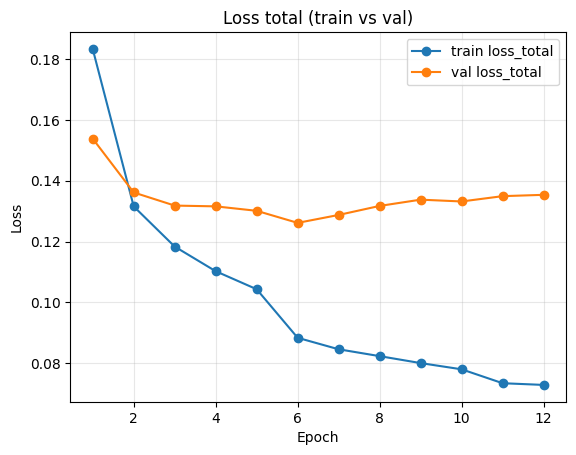

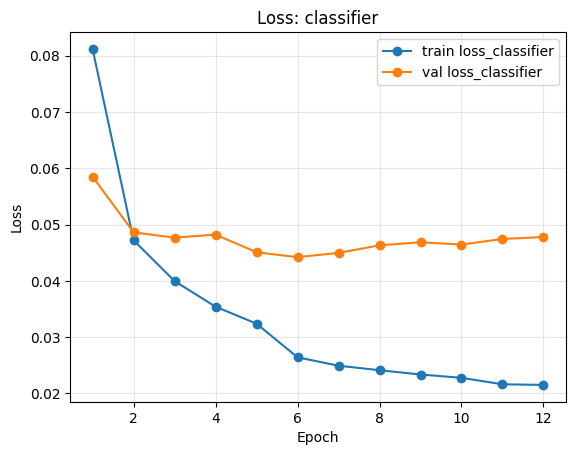

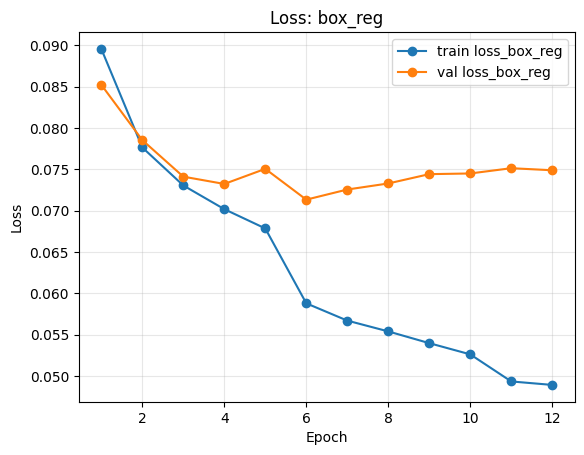

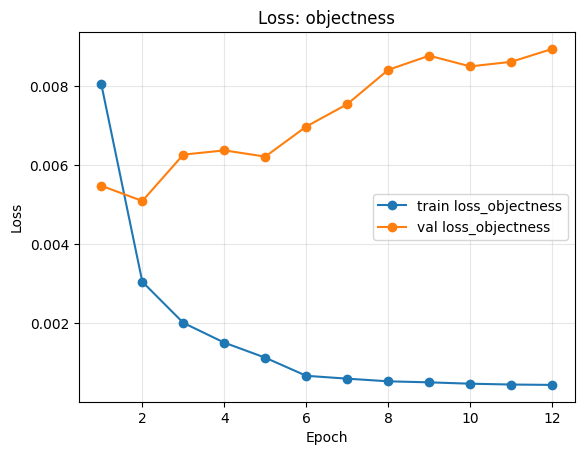

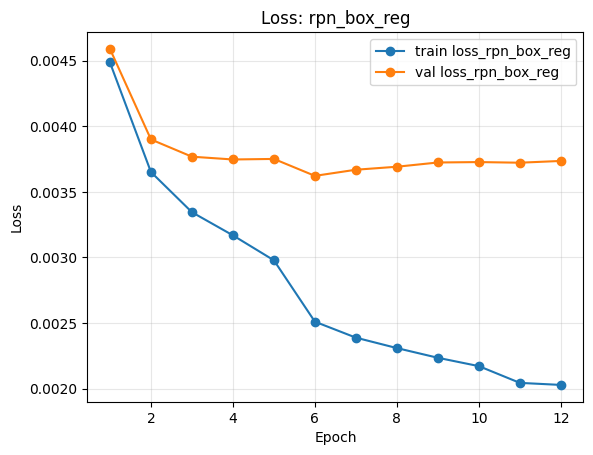

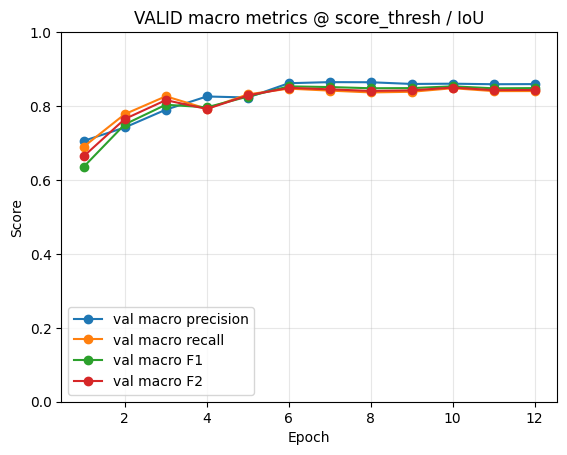

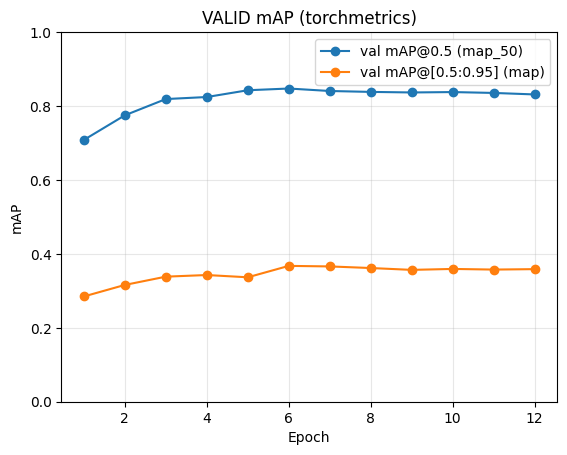

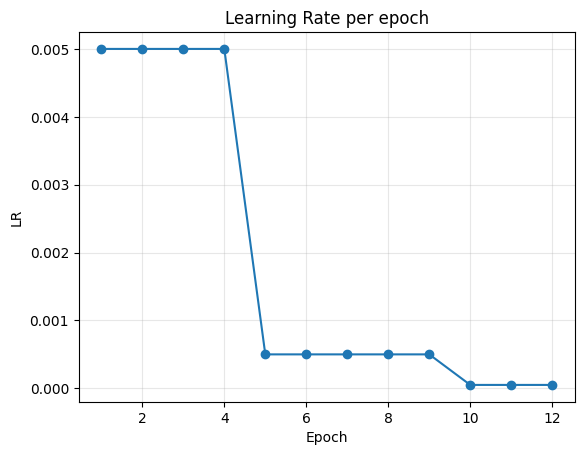

In [19]:
# ---------------------------------------
# 9) Graficar métricas por epoch
# ---------------------------------------

def _get(h, *keys, default=np.nan):
    cur = h
    for k in keys:
        if cur is None or not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur if cur is not None else default

epochs = [h["epoch"] for h in history]

# Series base (loss + LR)
train_loss = [_get(h, "train", "loss_total") for h in history]
val_loss   = [_get(h, "valid", "loss_total") for h in history]

train_cls  = [_get(h, "train", "loss_classifier") for h in history]
train_box  = [_get(h, "train", "loss_box_reg") for h in history]
train_obj  = [_get(h, "train", "loss_objectness") for h in history]
train_rpn  = [_get(h, "train", "loss_rpn_box_reg") for h in history]

val_cls    = [_get(h, "valid", "loss_classifier") for h in history]
val_box    = [_get(h, "valid", "loss_box_reg") for h in history]
val_obj    = [_get(h, "valid", "loss_objectness") for h in history]
val_rpn    = [_get(h, "valid", "loss_rpn_box_reg") for h in history]

lr_series  = [_get(h, "lr") for h in history]

# Series de métricas (macro)
val_prec = [_get(h, "valid_macro", "precision") for h in history]
val_rec  = [_get(h, "valid_macro", "recall") for h in history]
val_f1   = [_get(h, "valid_macro", "f1") for h in history]
val_f2   = [_get(h, "valid_macro", "f2") for h in history]

# mAP (si existe)
map50 = [_get(h, "valid_map", "map_50") for h in history]
map95 = [_get(h, "valid_map", "map") for h in history]
has_map = np.any(np.isfinite(map50)) or np.any(np.isfinite(map95))

# Loss total: train vs val
plt.figure()
plt.plot(epochs, train_loss, marker="o", label="train loss_total")
plt.plot(epochs, val_loss,   marker="o", label="val loss_total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss total (train vs val)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Breakdown de losses (train vs val)
plt.figure()
plt.plot(epochs, train_cls, marker="o", label="train loss_classifier")
plt.plot(epochs, val_cls,   marker="o", label="val loss_classifier")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss: classifier"); plt.grid(True, alpha=0.3); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, train_box, marker="o", label="train loss_box_reg")
plt.plot(epochs, val_box,   marker="o", label="val loss_box_reg")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss: box_reg"); plt.grid(True, alpha=0.3); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, train_obj, marker="o", label="train loss_objectness")
plt.plot(epochs, val_obj,   marker="o", label="val loss_objectness")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss: objectness"); plt.grid(True, alpha=0.3); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, train_rpn, marker="o", label="train loss_rpn_box_reg")
plt.plot(epochs, val_rpn,   marker="o", label="val loss_rpn_box_reg")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss: rpn_box_reg"); plt.grid(True, alpha=0.3); plt.legend(); plt.show()

# 3) Métricas macro en VALID (precision/recall/F1/F2)
plt.figure()
plt.plot(epochs, val_prec, marker="o", label="val macro precision")
plt.plot(epochs, val_rec,  marker="o", label="val macro recall")
plt.plot(epochs, val_f1,   marker="o", label="val macro F1")
plt.plot(epochs, val_f2,   marker="o", label="val macro F2")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("VALID macro metrics @ score_thresh / IoU")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# mAP en VALID
if has_map:
    plt.figure()
    plt.plot(epochs, map50, marker="o", label="val mAP@0.5 (map_50)")
    plt.plot(epochs, map95, marker="o", label="val mAP@[0.5:0.95] (map)")
    plt.xlabel("Epoch")
    plt.ylabel("mAP")
    plt.ylim(0, 1.0)
    plt.title("VALID mAP (torchmetrics)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("mAP no aparece en history.")

# Learning rate
plt.figure()
plt.plot(epochs, lr_series, marker="o")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate per epoch")
plt.grid(True, alpha=0.3)
plt.show()


In [20]:
print(f"Tiempo entrenamiento: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo entrenamiento: 0:00:01.095922


In [23]:
# ---------------------------------------
# 10) Guardado del modelo (pesos y checkpoint)
# ---------------------------------------

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = os.path.join(OUT_BASE_DIR, f"artifacts_{stamp}")
os.makedirs(OUT_DIR, exist_ok=True)

weights_path    = os.path.join(OUT_DIR, f"weights.pth")
checkpoint_path = os.path.join(OUT_DIR, f"frcnn_checkpoint.pth")
meta_path       = os.path.join(OUT_DIR, f"meta.json")

torch.save(model.state_dict(), weights_path)
print(f"[OK] Pesos guardados en: {weights_path}")

ckpt = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "epoch": EPOCHS,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": (416, 416),
    "lr": LR,
}
torch.save(ckpt, checkpoint_path)
print(f"[OK] Checkpoint guardado en: {checkpoint_path}")

meta = {
    "saved_at": stamp,
    "framework": "torchvision Faster R-CNN ResNet50-FPN",
    "device": str(device),
    "num_classes_with_bg": NUM_CLASSES_WITH_BG,
    "class_names": CLASS_NAMES,
    "train_imgs": len(train_ds),
    "valid_imgs": len(valid_ds),
    "test_imgs": len(test_ds),
    # "eval_valid_macro": eval_valid.get("macro", {}) if 'eval_valid' in locals() else {}
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print(f"[OK] Metadatos guardados en: {meta_path}")

[OK] Pesos guardados en: /content/drive/MyDrive/UBA/CEIA/Materias/Visión por Computadora II/google_colab_data/FasterR-CNN-ResNet50_notebook/artifacts_20251130_215020/weights.pth
[OK] Checkpoint guardado en: /content/drive/MyDrive/UBA/CEIA/Materias/Visión por Computadora II/google_colab_data/FasterR-CNN-ResNet50_notebook/artifacts_20251130_215020/frcnn_checkpoint.pth
[OK] Metadatos guardados en: /content/drive/MyDrive/UBA/CEIA/Materias/Visión por Computadora II/google_colab_data/FasterR-CNN-ResNet50_notebook/artifacts_20251130_215020/meta.json


In [24]:
print(f"Tiempo guardado modelo: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo guardado modelo: 0:00:01.289529


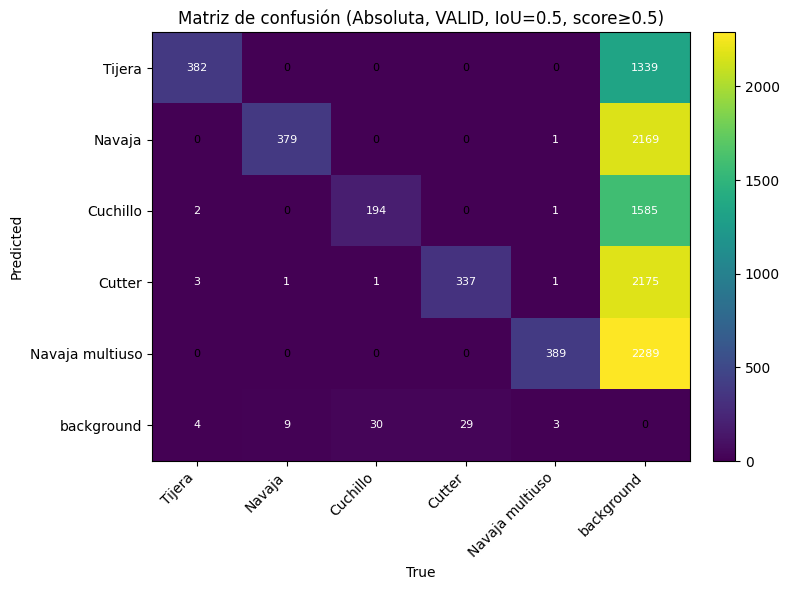

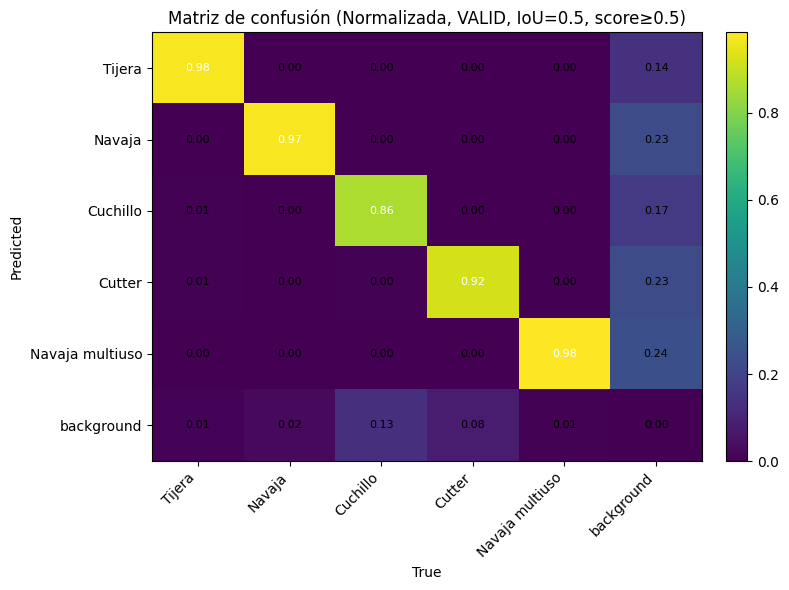

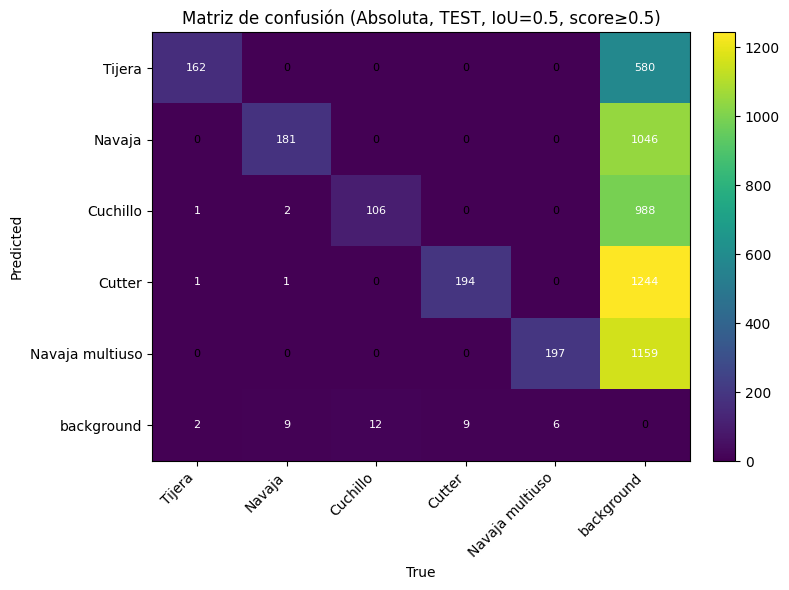

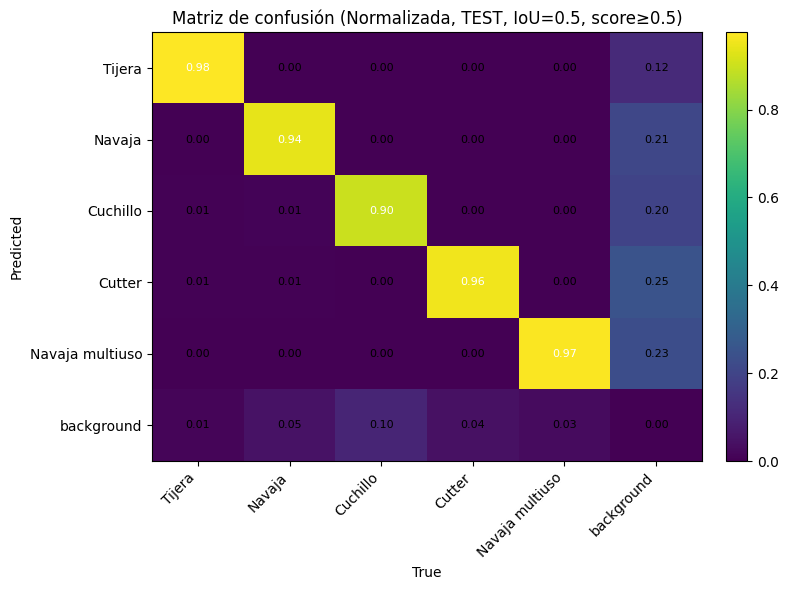

{'raw': array([[ 162,    0,    0,    0,    0,  580],
        [   0,  181,    0,    0,    0, 1046],
        [   1,    2,  106,    0,    0,  988],
        [   1,    1,    0,  194,    0, 1244],
        [   0,    0,    0,    0,  197, 1159],
        [   2,    9,   12,    9,    6,    0]]),
 'norm': array([[0.97590361, 0.        , 0.        , 0.        , 0.        ,
         0.11560694],
        [0.        , 0.93782383, 0.        , 0.        , 0.        ,
         0.20849113],
        [0.0060241 , 0.01036269, 0.89830508, 0.        , 0.        ,
         0.19693044],
        [0.0060241 , 0.00518135, 0.        , 0.95566502, 0.        ,
         0.24795695],
        [0.        , 0.        , 0.        , 0.        , 0.97044335,
         0.23101455],
        [0.01204819, 0.04663212, 0.10169492, 0.04433498, 0.02955665,
         0.        ]]),
 'labels': ['Tijera',
  'Navaja',
  'Cuchillo',
  'Cutter',
  'Navaja multiuso',
  'background']}

In [ ]:
# ---------------------------------------
# 11) Matriz de confusión (valid y test)
# ---------------------------------------

def _greedy_match_iou_class_first(pred_boxes, gt_boxes, pred_labels, gt_labels, iou_thresh=0.5):
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return []

    ious = box_iou(pred_boxes, gt_boxes).cpu().numpy()
    matches = []
    used_pred, used_gt = set(), set()

    def _run(flat_pairs):
        nonlocal matches, used_pred, used_gt
        for i, j, v in flat_pairs:
            if v < iou_thresh:
                break
            if (i not in used_pred) and (j not in used_gt):
                used_pred.add(i); used_gt.add(j)
                matches.append((i, j))

    # Construir pares (i, j, iou)
    flat_same = []
    flat_diff = []
    for i in range(ious.shape[0]):
        for j in range(ious.shape[1]):
            v = ious[i, j]
            if pred_labels[i] == gt_labels[j]:
                flat_same.append((i, j, v))
            else:
                flat_diff.append((i, j, v))

    flat_same.sort(key=lambda x: x[2], reverse=True)
    flat_diff.sort(key=lambda x: x[2], reverse=True)

    _run(flat_same)  # etapa 1: aciertos
    _run(flat_diff)  # etapa 2: confusiones

    return matches


def confusion_matrix_detection(model, loader, class_names, score_thresh=0.5, iou_thresh=0.5, normalize=True, title="Confusion Matrix"):
    model.eval()
    K = len(class_names)
    C = np.zeros((K+1, K+1), dtype=np.int64)  # filas=pred, cols=true ; ultimo índice = background
    bg = K  # índice background

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = [img.to(device) for img in imgs]
            outs = model(imgs)

            for out, tgt in zip(outs, targets):
                # Filtrar por score
                keep = out["scores"].cpu().numpy() >= score_thresh
                p_boxes = out["boxes"][keep].cpu()
                p_labels = out["labels"][keep].cpu().numpy()  # en 1..K

                g_boxes  = tgt["boxes"].cpu()
                g_labels = tgt["labels"].cpu().numpy()        # en 1..K

                # Emparejar por IoU (class-agnostic) para poder medir confusiones entre clases. Pasar labels a 0..K-1 para el matching
                p_labels0 = (p_labels.astype(int) - 1)
                g_labels0 = (g_labels.astype(int) - 1)

                matches = _greedy_match_iou_class_first(p_boxes, g_boxes, p_labels0, g_labels0, iou_thresh=iou_thresh)

                matched_pred = set(i for i, _ in matches)
                matched_gt   = set(j for _, j in matches)

                # Contar matches (pueden ser aciertos o confusiones de clase)
                for i, j in matches:
                  pred_c = int(p_labels0[i])
                  true_c = int(g_labels0[j])
                  C[pred_c, true_c] += 1

                # Predicciones no emparejadas -> true = background
                for i in range(len(p_boxes)):
                    if i not in matched_pred:
                        pred_c = int(p_labels[i]) - 1
                        C[pred_c, bg] += 1

                # GT no emparejadas -> pred = background
                for j in range(len(g_boxes)):
                    if j not in matched_gt:
                        true_c = int(g_labels[j]) - 1
                        C[bg, true_c] += 1

    # Normalización por columna
    Cn = C.astype(float)
    if normalize:
        col_sums = Cn.sum(axis=0, keepdims=True)
        col_sums[col_sums == 0] = 1.0
        Cn = Cn / col_sums

    # Plot
    labels_plot = class_names + ["background"]
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(Cn, interpolation='nearest', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_xticks(range(len(labels_plot)))
    ax.set_yticks(range(len(labels_plot)))
    ax.set_xticklabels(labels_plot, rotation=45, ha='right')
    ax.set_yticklabels(labels_plot)

    # Anotar valores
    for i in range(Cn.shape[0]):
        for j in range(Cn.shape[1]):
            val = Cn[i, j]
            txt = f"{val:.2f}" if normalize else str(C[i, j])
            ax.text(j, i, txt, ha='center', va='center', color='white' if val > 0.5 else 'black', fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return {"raw": C, "norm": Cn, "labels": labels_plot}

# Una matriz absoluta y normalizada para VALID y otra para TEST
confusion_matrix_detection(model, valid_dl, CLASS_NAMES, score_thresh=model.roi_heads.score_thresh, iou_thresh=0.5,
                           normalize=False, title="Matriz de confusión (Absoluta, VALID, IoU=0.5, score≥0.5)")
confusion_matrix_detection(model, valid_dl, CLASS_NAMES, score_thresh=model.roi_heads.score_thresh, iou_thresh=0.5,
                           normalize=True, title="Matriz de confusión (Normalizada, VALID, IoU=0.5, score≥0.5)")
confusion_matrix_detection(model, test_dl,  CLASS_NAMES, score_thresh=model.roi_heads.score_thresh, iou_thresh=0.5,
                           normalize=False, title="Matriz de confusión (Absoluta, TEST, IoU=0.5, score≥0.5)")
confusion_matrix_detection(model, test_dl,  CLASS_NAMES, score_thresh=model.roi_heads.score_thresh, iou_thresh=0.5,
                           normalize=True, title="Matriz de confusión (Normalizada, TEST, IoU=0.5, score≥0.5)")


NOTA: Para este entrenamiento los títulos de las matrices de confusión quedaron harcodeados. Donde dice *"score≥0.5"* debería decir *"score≥0.01"*.

In [28]:
print(f"Tiempo matrices confusión: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo matrices confusión: 0:01:39.257494


In [29]:
# ---------------------------------------
# 12) Recolectar métricas y guardar en JSON
# ---------------------------------------

if 'train_loss_history' not in globals():
    train_loss_history = []

def summarize_eval(eval_dict, split_name):
    """Convierte la salida de evaluate_prf1(...) al esquema JSON estandar."""
    if eval_dict is None:
        return None
    per_class = []
    for (name, tp, fp, fn, prec, rec, f1) in eval_dict["per_class"]:
        per_class.append({
            "class": name,
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
        })
    # totales (sin background)
    TP = int(eval_dict["raw"]["TP"][1:].sum())
    FP = int(eval_dict["raw"]["FP"][1:].sum())
    FN = int(eval_dict["raw"]["FN"][1:].sum())
    return {
        "split": split_name,
        "macro": {
            "precision": float(eval_dict["macro"]["precision"]),
            "recall":    float(eval_dict["macro"]["recall"]),
            "f1":        float(eval_dict["macro"]["f1"]),
        },
        "totals": {"TP": TP, "FP": FP, "FN": FN},
        "per_class": per_class,
        "thresholds": {"iou": 0.5, "score": 0.5}
    }

def is_backbone_frozen(m):
    try:
        return all((not p.requires_grad) for p in m.backbone.parameters())
    except Exception:
        return None

# Información del optimizador/scheduler
opt_name = optimizer.__class__.__name__ if 'optimizer' in globals() else None
sch_name = lr_sched.__class__.__name__ if 'lr_sched' in globals() else None

# Build del JSON
stamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
payload = {
    "saved_at": stamp,
    "notebook": "CEIA_VpC2_TP_Opcion2.ipynb",
    "framework": "torchvision Faster R-CNN ResNet50-FPN",
    "device": str(device),
    "classes": CLASS_NAMES,
    "num_classes": len(CLASS_NAMES),
    "data": {
        "train_images": len(train_ds) if 'train_ds' in globals() else None,
        "valid_images": len(valid_ds) if 'valid_ds' in globals() else None,
        "test_images":  len(test_ds)  if 'test_ds'  in globals() else None
    },
    "training": {
        "epochs": EPOCHS if 'EPOCHS' in globals() else None,
        "batch_size": BATCH_SIZE if 'BATCH_SIZE' in globals() else None,
        "lr": LR if 'LR' in globals() else None,
        "optimizer": opt_name,
        "scheduler": sch_name,
        "backbone_frozen": is_backbone_frozen(model),
        "loss_history": train_loss_history,
    },
}

path_metrics_full = os.path.join(OUT_DIR, "metrics_full.json")

with open(path_metrics_full, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

print(f"[OK] Métricas guardadas:\n  - {path_metrics_full}")

[OK] Métricas guardadas:
  - /content/drive/MyDrive/UBA/CEIA/Materias/Visión por Computadora II/google_colab_data/FasterR-CNN-ResNet50_notebook/artifacts_20251130_215020/metrics_full.json


In [30]:
print(f"Tiempo recolección métricas: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo recolección métricas: 0:00:00.021600


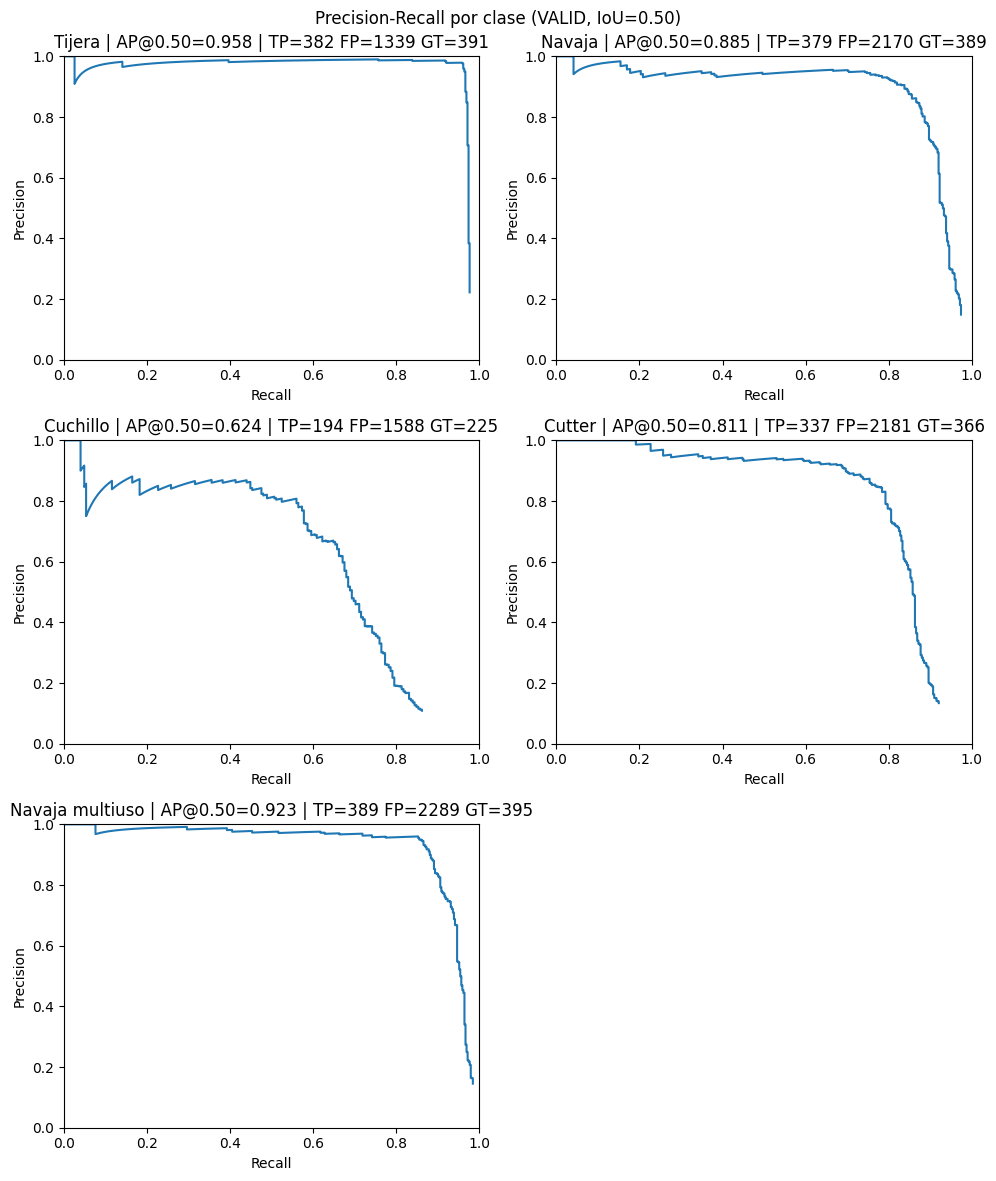


=== Resultados AP/mAP @ IoU=0.50 (VALID) ===
  Tijera              : AP=0.958
  Navaja              : AP=0.885
  Cuchillo            : AP=0.624
  Cutter              : AP=0.811
  Navaja multiuso     : AP=0.923
  mAP@0.50: 0.840

=== Resultados AP/mAP @ IoU=0.50 (VALID) ===
  Tijera              : AP=0.958
  Navaja              : AP=0.885
  Cuchillo            : AP=0.624
  Cutter              : AP=0.811
  Navaja multiuso     : AP=0.923
  mAP@0.50: 0.840

=== Resultados AP/mAP @ IoU=0.55 (VALID) ===
  Tijera              : AP=0.937
  Navaja              : AP=0.822
  Cuchillo            : AP=0.545
  Cutter              : AP=0.787
  Navaja multiuso     : AP=0.887
  mAP@0.55: 0.796

=== Resultados AP/mAP @ IoU=0.60 (VALID) ===
  Tijera              : AP=0.916
  Navaja              : AP=0.737
  Cuchillo            : AP=0.432
  Cutter              : AP=0.729
  Navaja multiuso     : AP=0.794
  mAP@0.60: 0.722

=== Resultados AP/mAP @ IoU=0.65 (VALID) ===
  Tijera              : AP=0.832
  Nav

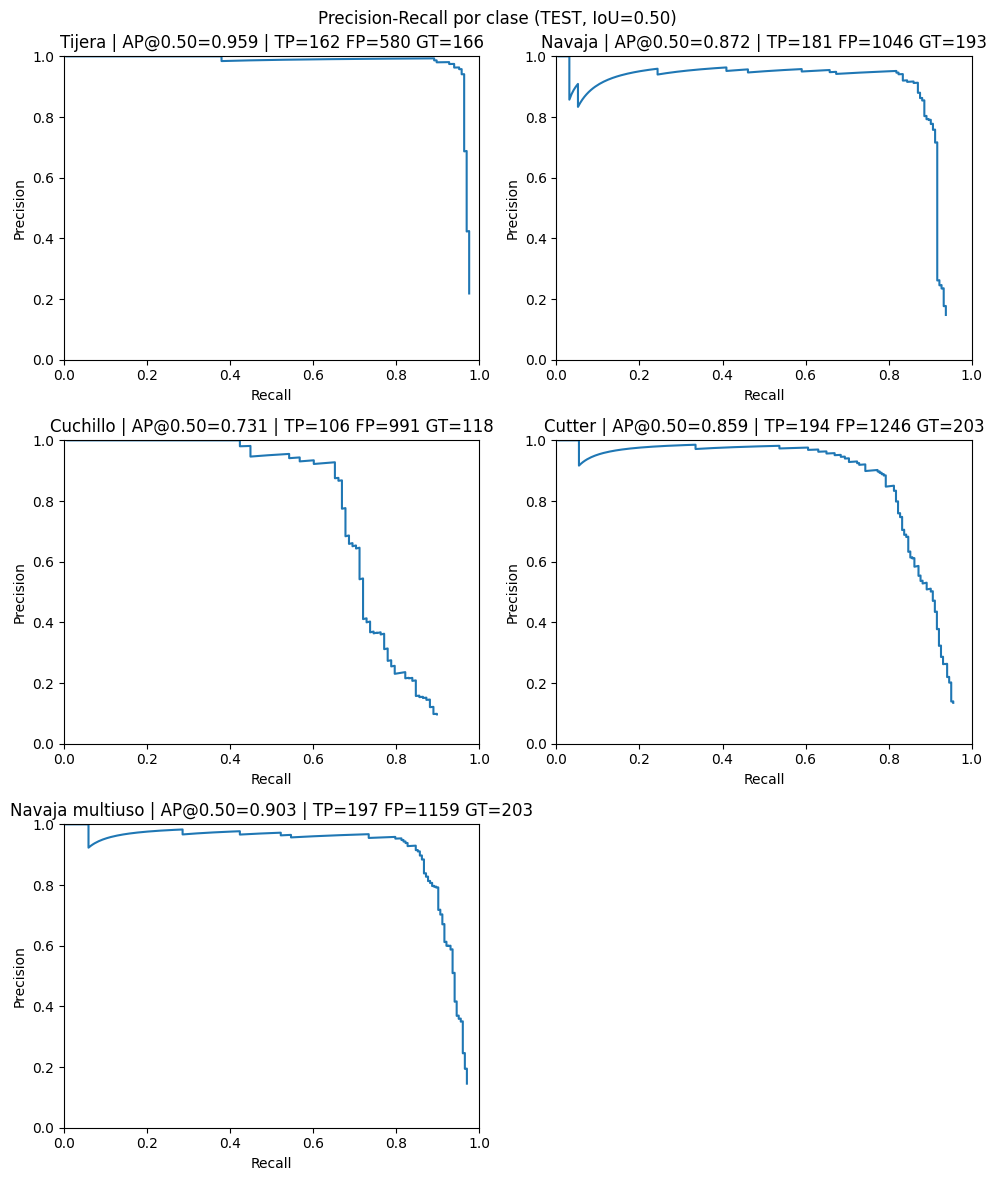


=== Resultados AP/mAP @ IoU=0.50 (TEST) ===
  Tijera              : AP=0.959
  Navaja              : AP=0.872
  Cuchillo            : AP=0.731
  Cutter              : AP=0.859
  Navaja multiuso     : AP=0.903
  mAP@0.50: 0.865

=== Resultados AP/mAP @ IoU=0.50 (TEST) ===
  Tijera              : AP=0.959
  Navaja              : AP=0.872
  Cuchillo            : AP=0.731
  Cutter              : AP=0.859
  Navaja multiuso     : AP=0.903
  mAP@0.50: 0.865

=== Resultados AP/mAP @ IoU=0.55 (TEST) ===
  Tijera              : AP=0.930
  Navaja              : AP=0.843
  Cuchillo            : AP=0.656
  Cutter              : AP=0.822
  Navaja multiuso     : AP=0.857
  mAP@0.55: 0.821

=== Resultados AP/mAP @ IoU=0.60 (TEST) ===
  Tijera              : AP=0.893
  Navaja              : AP=0.791
  Cuchillo            : AP=0.598
  Cutter              : AP=0.767
  Navaja multiuso     : AP=0.791
  mAP@0.60: 0.768

=== Resultados AP/mAP @ IoU=0.65 (TEST) ===
  Tijera              : AP=0.785
  Navaja  

In [31]:
# ---------------------------------------
# 13) Curvas P-R por clase y mAP (mAP@0.5 y mAP@[0.5:0.95])
# ---------------------------------------


@torch.no_grad()
def _collect_predictions_and_gts(model, loader, device, num_classes, score_min=0.0):
    model.eval()
    preds_by_cls = {c: [] for c in range(1, num_classes+1)}
    gts_by_cls   = {c: [] for c in range(1, num_classes+1)}

    img_index = 0
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        outs = model(imgs)

        for out, tgt in zip(outs, targets):
            # GT
            gt_boxes  = tgt["boxes"].cpu().numpy()
            gt_labels = tgt["labels"].cpu().numpy()  # 1..K
            for b, lab in zip(gt_boxes, gt_labels):
                gts_by_cls[int(lab)].append((b[0], b[1], b[2], b[3], img_index))

            # Preds
            scores = out["scores"].cpu().numpy()
            keep = scores >= score_min
            p_boxes  = out["boxes"][keep].cpu().numpy()
            p_labels = out["labels"][keep].cpu().numpy()  # 1..K
            p_scores = scores[keep]

            for b, lab, sc in zip(p_boxes, p_labels, p_scores):
                preds_by_cls[int(lab)].append((float(sc), b[0], b[1], b[2], b[3], img_index))

            img_index += 1
    return preds_by_cls, gts_by_cls

def _ap_from_pr(precision, recall):
    if len(precision) == 0:
        return 0.0
    # Ordenar por recall ascendente
    order = np.argsort(recall)
    r = np.array(recall)[order]
    p = np.array(precision)[order]

    # Precision envelope: p[i] = max_{j>=i} p[j]
    for i in range(len(p)-2, -1, -1):
        p[i] = max(p[i], p[i+1])

    # Muestreamos 101 puntos de recall
    recall_grid = np.linspace(0, 1, 101)
    p_interp = np.zeros_like(recall_grid)
    for i, rg in enumerate(recall_grid):
        idx = np.where(r >= rg)[0]
        p_interp[i] = 0.0 if len(idx) == 0 else np.max(p[idx])
    return float(np.mean(p_interp))

def _pr_curve_for_class(preds_cls, gts_cls, iou_thresh=0.5):
    # Índice de GTs por imagen para acelerar matching
    gt_by_img = {}
    for (x1, y1, x2, y2, img_id) in gts_cls:
        gt_by_img.setdefault(img_id, []).append([x1, y1, x2, y2, False])  # False = no emparejada todavía

    # Ordenar predicciones por score descendente
    preds_cls = sorted(preds_cls, key=lambda x: x[0], reverse=True)

    tp = np.zeros(len(preds_cls), dtype=np.float32)
    fp = np.zeros(len(preds_cls), dtype=np.float32)
    total_gts = len(gts_cls)

    for i, (score, x1, y1, x2, y2, img_id) in enumerate(preds_cls):
        pred_box = np.array([[x1, y1, x2, y2]], dtype=np.float32)
        gts_list = gt_by_img.get(img_id, [])

        if len(gts_list) == 0:
            fp[i] = 1.0
            continue

        # IoU con todas las GTs de esta imagen para esta clase
        gt_boxes = np.array([g[:4] for g in gts_list], dtype=np.float32)
        ious = box_iou(torch.tensor(pred_box), torch.tensor(gt_boxes)).numpy()[0]

        # Mejor IoU
        best_idx = int(np.argmax(ious))
        best_iou = float(ious[best_idx])

        if best_iou >= iou_thresh and (not gts_list[best_idx][4]):  # no emparejada
            tp[i] = 1.0
            gts_list[best_idx][4] = True  # marcar como usada
        else:
            fp[i] = 1.0

    # Cálculo de precisión y recall acumulados
    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)
    precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    recall = cum_tp / max(total_gts, 1e-9)

    ap = _ap_from_pr(precision, recall)
    return precision, recall, ap, int(cum_tp[-1]) if len(cum_tp) else 0, int(cum_fp[-1]) if len(cum_fp) else 0, total_gts

def compute_map(model, loader, class_names, device, iou_list=(0.5,), score_min=0.0, plot_pr=True, title_prefix="VALID"):
    K = len(class_names)
    preds_by_cls, gts_by_cls = _collect_predictions_and_gts(model, loader, device, K, score_min=score_min)

    aps_per_iou = []
    pr_cache = {}  # para el primer IoU (plot)

    for iou in iou_list:
        ap_classes = []
        for cls_id in range(1, K+1):
            precision, recall, ap, tps, fps, total_gts = _pr_curve_for_class(preds_by_cls[cls_id], gts_by_cls[cls_id], iou_thresh=iou)
            ap_classes.append(ap)
            if iou == iou_list[0]:  # cachear para plot
                pr_cache[cls_id] = (precision, recall, ap, tps, fps, total_gts)

        mAP = float(np.mean(ap_classes)) if len(ap_classes) else 0.0
        aps_per_iou.append((iou, ap_classes, mAP))

    # Plot P-R (solo para el primer IoU)
    if plot_pr:
        cols = 2
        rows = int(np.ceil(K / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(10, 4*rows), squeeze=False)
        i = 0
        for r in range(rows):
            for c in range(cols):
                ax = axes[r][c]
                i += 1
                if i <= K:
                    P, R, APc, TPc, FPc, GTc = pr_cache[i]
                    ax.plot(R, P)
                    ax.set_title(f"{class_names[i-1]} | AP@{iou_list[0]:.2f}={APc:.3f} | TP={TPc} FP={FPc} GT={GTc}")
                    ax.set_xlabel("Recall")
                    ax.set_ylabel("Precision")
                    ax.set_xlim(0, 1)
                    ax.set_ylim(0, 1)
                else:
                    ax.axis("off")
        plt.suptitle(f"Precision-Recall por clase ({title_prefix}, IoU={iou_list[0]:.2f})")
        plt.tight_layout()
        plt.show()

    # Reporte numérico
    for iou, ap_classes, mAP in aps_per_iou:
        print(f"\n=== Resultados AP/mAP @ IoU={iou:.2f} ({title_prefix}) ===")
        for ci, ap in enumerate(ap_classes, start=1):
            print(f"  {class_names[ci-1]:20s}: AP={ap:.3f}")
        print(f"  mAP@{iou:.2f}: {mAP:.3f}")

    return aps_per_iou  # lista de (iou, [AP_cls], mAP)

# Ejecutar en VALID
# mAP@0.5
aps_valid_05 = compute_map(model, valid_dl, CLASS_NAMES, device, iou_list=(0.5,), score_min=0.0, plot_pr=True, title_prefix="VALID")
# mAP@[0.5:0.95] (COCO)
iou_grid = tuple(np.round(np.arange(0.5, 0.96, 0.05), 2))
aps_valid_COCO = compute_map(model, valid_dl, CLASS_NAMES, device, iou_list=iou_grid, score_min=0.0, plot_pr=False, title_prefix="VALID")

# Ejecutar en TEST
aps_test_05 = compute_map(model, test_dl, CLASS_NAMES, device, iou_list=(0.5,), score_min=0.0, plot_pr=True, title_prefix="TEST")
aps_test_COCO = compute_map(model, test_dl, CLASS_NAMES, device, iou_list=iou_grid, score_min=0.0, plot_pr=False, title_prefix="TEST")


In [32]:
print(f"Tiempo preparación curvas: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo preparación curvas: 0:02:04.370755



=== Barrido de umbral (VALID, IoU=0.50) ===
  score=0.05  →  Macro-F1=0.481
  score=0.10  →  Macro-F1=0.599
  score=0.15  →  Macro-F1=0.659
  score=0.20  →  Macro-F1=0.699
  score=0.25  →  Macro-F1=0.725
  score=0.30  →  Macro-F1=0.747
  score=0.35  →  Macro-F1=0.766
  score=0.40  →  Macro-F1=0.781
  score=0.45  →  Macro-F1=0.791
  score=0.50  →  Macro-F1=0.799
  score=0.55  →  Macro-F1=0.803
  score=0.60  →  Macro-F1=0.811
  score=0.65  →  Macro-F1=0.819
  score=0.70  →  Macro-F1=0.825
  score=0.75  →  Macro-F1=0.825
  score=0.80  →  Macro-F1=0.823
  score=0.85  →  Macro-F1=0.824
  score=0.90  →  Macro-F1=0.820
  score=0.95  →  Macro-F1=0.807

Mejor umbral: score=0.70  →  Macro-F1=0.825


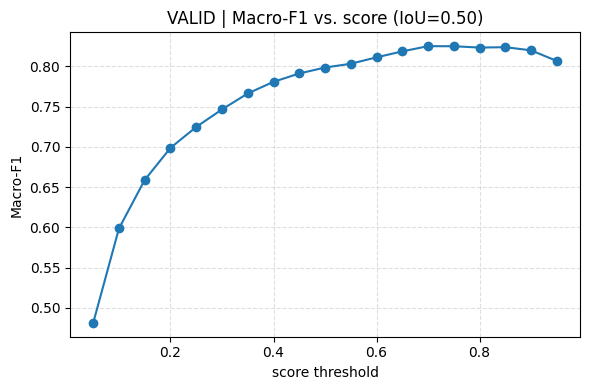

[OK] Barrido de umbral agregado al payload de métricas (VALID).
BEST_SCORE_FOR_INFERENCE = 0.70


In [ ]:
# ---------------------------------------
# 14) Barrido de umbral de score → Macro-F1 vs. score (en VALID)
# ---------------------------------------

@torch.no_grad()
def evaluate_prf1(model, loader, device, class_names, score_thresh=0.5, iou_thresh=0.5):
    model.eval()
    K = len(class_names)
    TP = np.zeros(K+1, dtype=np.int64)
    FP = np.zeros(K+1, dtype=np.int64)
    FN = np.zeros(K+1, dtype=np.int64)

    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        outs = model(imgs)

        for out, tgt in zip(outs, targets):
            gt_boxes = tgt["boxes"].cpu()
            gt_labels = tgt["labels"].cpu()  # 1..K

            keep = out["scores"].cpu() >= score_thresh
            pred_boxes = out["boxes"][keep].cpu()
            pred_labels = out["labels"][keep].cpu()  # 1..K
            pred_scores = out["scores"][keep].cpu()

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            ious = box_iou(pred_boxes, gt_boxes) if (len(pred_boxes)>0 and len(gt_boxes)>0) else torch.zeros((len(pred_boxes), len(gt_boxes)))

            matched_gt = set()
            matched_pred = set()

            # greedy por score desc, y match por clase + IoU
            order = torch.argsort(pred_scores, descending=True).cpu().numpy()
            for pi in order:
                best_j, best_iou = -1, 0.0
                for gj in range(len(gt_boxes)):
                    if gj in matched_gt:
                        continue
                    if pred_labels[pi].item() != gt_labels[gj].item():
                        continue
                    iou_val = float(ious[pi, gj].item())
                    if iou_val >= iou_thresh and iou_val > best_iou:
                        best_iou, best_j = iou_val, gj
                if best_j >= 0:
                    cls = int(pred_labels[pi].item())
                    TP[cls] += 1
                    matched_pred.add(pi)
                    matched_gt.add(best_j)

            for pi in range(len(pred_boxes)):
                if pi not in matched_pred:
                    cls = int(pred_labels[pi].item())
                    FP[cls] += 1

            for gj in range(len(gt_boxes)):
                if gj not in matched_gt:
                    cls = int(gt_labels[gj].item())
                    FN[cls] += 1

    results = []
    for cls in range(1, K+1):
        tp, fp, fn = TP[cls], FP[cls], FN[cls]
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        results.append((class_names[cls-1], tp, fp, fn, prec, rec, f1))

    macro_prec = float(np.mean([r[4] for r in results])) if results else 0.0
    macro_rec  = float(np.mean([r[5] for r in results])) if results else 0.0
    macro_f1   = float(np.mean([r[6] for r in results])) if results else 0.0

    return {"per_class": results, "macro": {"precision": macro_prec, "recall": macro_rec, "f1": macro_f1}}
    

def sweep_threshold_macro_f1(model, loader, device, class_names,
                             iou_thresh=0.5,
                             scores=np.linspace(0.05, 0.95, 19)):
    model.eval()
    macro_f1 = []
    for s in scores:
        out = evaluate_prf1(model, loader, device, class_names,
                            score_thresh=float(s), iou_thresh=float(iou_thresh))
        macro_f1.append(out["macro"]["f1"])
    macro_f1 = np.array(macro_f1, dtype=float)

    # Mejor umbral
    best_idx = int(np.argmax(macro_f1))
    best_score = float(scores[best_idx])
    best_macro_f1 = float(macro_f1[best_idx])

    # Print detallado
    print(f"\n=== Barrido de umbral (VALID, IoU={iou_thresh:.2f}) ===")
    for s, f in zip(scores, macro_f1):
        print(f"  score={s:>4.2f}  →  Macro-F1={f:0.3f}")
    print(f"\nMejor umbral: score={best_score:.2f}  →  Macro-F1={best_macro_f1:.3f}")

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(scores, macro_f1, marker='o')
    plt.title(f"VALID | Macro-F1 vs. score (IoU={iou_thresh:.2f})")
    plt.xlabel("score threshold")
    plt.ylabel("Macro-F1")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return {
        "scores": scores.tolist(),
        "macro_f1": macro_f1.tolist(),
        "best_score": best_score,
        "best_macro_f1": best_macro_f1
    }

# Ejecutar barrido en VALID
score_sweep_valid = sweep_threshold_macro_f1(model, valid_dl, device, CLASS_NAMES, iou_thresh=0.5)

if 'payload' in globals():
    payload.setdefault("results", {}).setdefault("valid", {})
    payload["results"]["valid"]["score_sweep"] = {
        "scores": score_sweep_valid["scores"],
        "macro_f1": score_sweep_valid["macro_f1"],
        "best_score": score_sweep_valid["best_score"],
        "best_macro_f1": score_sweep_valid["best_macro_f1"],
        "iou": 0.5
    }
    print("[OK] Barrido de umbral agregado al payload de métricas (VALID).")

# Usar el mejor umbral para inferencia/validación rápida:
BEST_SCORE_FOR_INFERENCE = score_sweep_valid["best_score"]
print(f"BEST_SCORE_FOR_INFERENCE = {BEST_SCORE_FOR_INFERENCE:.2f}")

In [34]:
print(f"Tiempo preparación barrido umbral: {datetime.datetime.now() - INICIO_STEP}")
INICIO_STEP = datetime.datetime.now()

Tiempo preparación barrido umbral: 0:10:10.539406


In [35]:
print(f"Tiempo total ejecución: {datetime.datetime.now() - INICIO_EJECUCION}")

Tiempo total ejecución: 1:18:00.128646


---

## Análisis de resultados ##

### Mejores métricas por época (VALID)
El comportamiento por época es similar al entrenamiento 1: mejora fuerte temprano y luego entre en una meseta.
- **Best mAP en VALID:** época ~6 (`val_mAP50≈0.847`, `val_mAP≈0.368`)
- **Best Recall/F2 en VALID:** época ~10 (`val_rec≈0.848`, `val_f2≈0.850`)
En general, las métricas por época quedan muy parecidas al entrenamiento 1, lo cual es coherente porque el cambio principal de este entrenamiento es el **operating point**.

### Matrices de confusión (IoU=0.5)
**Importante:** en el entrenamiento 2 las matrices están calculadas con **score_thresh=0.01** (aunque el título diga 0.5).  
Esto cambia el trade-off: **menos FN (misses) pero más FP (predicciones no matcheadas)**.

#### VALID: entrenamiento 1 vs. entreamiento 2
- **FN totales** bajan fuerte:  
  - Entrenamiento 1: **191**  →  Entrenamiento 2: **75**
- Por clase (FN a background) mejora justo donde más impactaba:
  - **Cuchillo:** 65 → **30**
  - **Cutter:** 55 → **29**
- **FP totales (columna background)** suben al bajar el umbral:  
  - 163 → **9557** (coherente con `score=0.01` + `detections_per_img=50`)

#### TEST: entrenamiento 1 vs. entrenamiento 2
- **FN totales** también bajan mucho:  
  - Entrenamiento 1: **106** → Entrenamiento 2: **38**
- Mejora fuerte en las clases críticas:
  - **Cuchillo:** 24 → **12**
  - **Cutter:** 33 → **9**
- Y el costo vuelve a ser **FP** muy altos:  
  - 97 → **5017**

### Conclusión general
- Entrenamiento 2 confirma que el problema dominante era **no detectar** (FN), especialmente en **Cuchillo/Cutter**, y que bajar el umbral a `score=0.01` **recupera muchas detecciones**.
- El costo es muchas detecciones no matcheadas (FP).  
  Esto valida el enfoque de “operating point” (evitar el peligro), pero muestra que el próximo paso debe apuntar a subir recall sin subir los FP, es decir: mejorar el modelo (p.ej. augmentation “segura”, anchors/RPN, etc.) para que podamos usar umbrales menos agresivos manteniendo recall alto.


---